LOADING DATASET

In [8]:
!kaggle datasets download -d surajkumarjha1/fake-vs-real-medicine-datasets-images

Dataset URL: https://www.kaggle.com/datasets/surajkumarjha1/fake-vs-real-medicine-datasets-images
License(s): unknown
100% 267M/267M [00:07<00:00, 35.1MB/s]



In [9]:
!unzip fake-vs-real-medicine-datasets-images.zip

Archive:  fake-vs-real-medicine-datasets-images.zip
  inflating: dataset/Fake/Screenshot 2025-09-17 173830.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 173925.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 173947.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174004.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174048.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174103.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174126.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174153.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174239.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174308.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174345.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174416.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174538.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174557.png  
  inflating: dataset/Fake/Screenshot 2025-09-17 174626.png  
  inflating: dataset/Fake/Screens

In [10]:
import os

os.listdir()

['.config',
 'fake-vs-real-medicine-datasets-images.zip',
 'dataset',
 'sample_data']

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
train_path = "/content/dataset/train"
valid_path = "/content/dataset/val"

In [103]:
plt.suptitle("Sample Medicine Images")

plt.savefig("sample_medicine_images.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

preprocessing and training,testing

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [18]:
print(train_generator.directory)

/content/dataset/train


In [19]:
import os

print(os.listdir("/content/dataset"))

['train', 'Real', 'val', 'test', 'Fake']


In [20]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 661 images belonging to 2 classes.
Found 453 images belonging to 2 classes.


In [21]:
train_count = sum([len(files) for r, d, files in os.walk('/content/dataset/train')])
val_count = sum([len(files) for r, d, files in os.walk('/content/dataset/val')])
test_count = sum([len(files) for r, d, files in os.walk('/content/dataset/test')])

print("Training Images:", train_count)
print("Validation Images:", val_count)
print("Test Images:", test_count)

Training Images: 662
Validation Images: 454
Test Images: 450


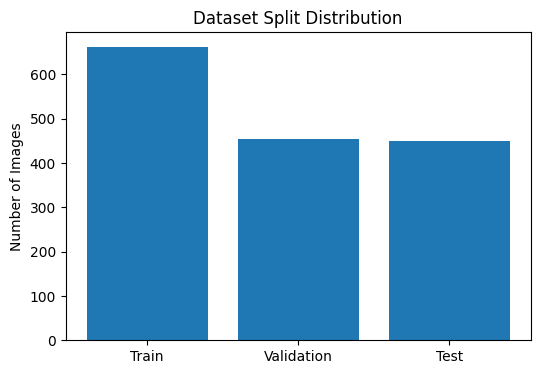

In [22]:
import matplotlib.pyplot as plt

sets = ['Train', 'Validation', 'Test']
counts = [train_count, val_count, test_count]

plt.figure(figsize=(6,4))
plt.bar(sets, counts)

plt.title("Dataset Split Distribution")
plt.ylabel("Number of Images")

plt.savefig("dataset_split.png", dpi=300)
plt.show()

In [102]:
plt.savefig("dataset_split_distribution.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

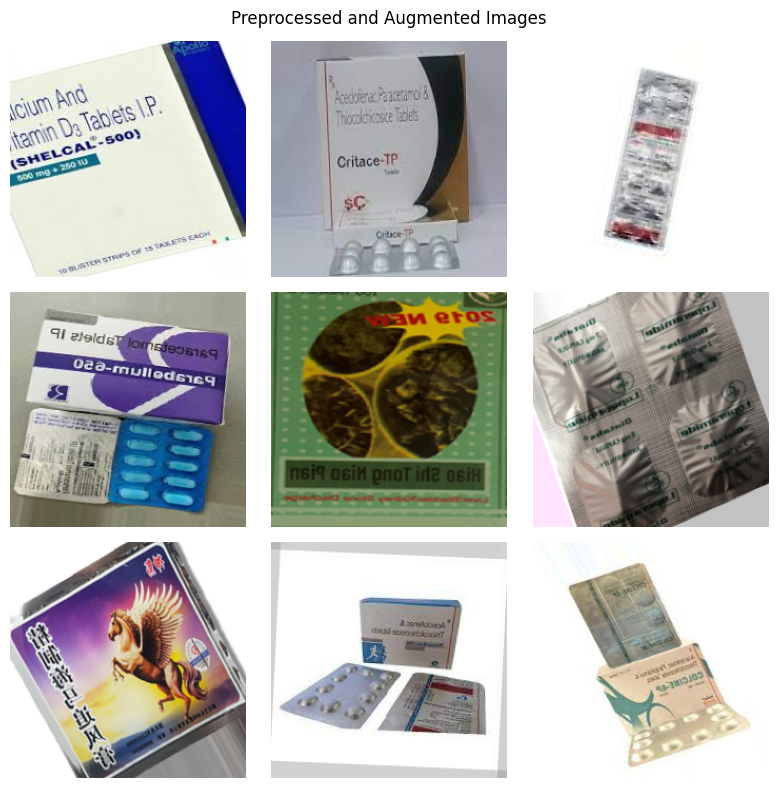

In [15]:
images, labels = next(train_generator)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Preprocessed and Augmented Images")
plt.tight_layout()
plt.show()

In [16]:
images, labels = next(train_generator)

print("Image Batch Shape:", images.shape)
print("Minimum Pixel Value:", images.min())
print("Maximum Pixel Value:", images.max())

Image Batch Shape: (32, 224, 224, 3)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


CNN MODEL

In [41]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.6324 - loss: 0.8768 - val_accuracy: 0.7439 - val_loss: 0.4941
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.7322 - loss: 0.5570 - val_accuracy: 0.7196 - val_loss: 0.5050
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.7474 - loss: 0.5061 - val_accuracy: 0.7925 - val_loss: 0.4366
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.8169 - loss: 0.4018 - val_accuracy: 0.7395 - val_loss: 0.5554
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 96s 5s/step - accuracy: 0.8154 - loss: 0.4058 - val_accuracy: 0.8587 - val_loss: 0.2955
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8850 - loss: 0.2911 - val_accuracy: 0.9338 - val_loss: 0.1932
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8775 - loss: 0.2874 - val_accuracy: 0.9073 - val_loss: 0.2183
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.8850 - loss: 0.2693 - val_accuracy: 0.9603 - val_loss:

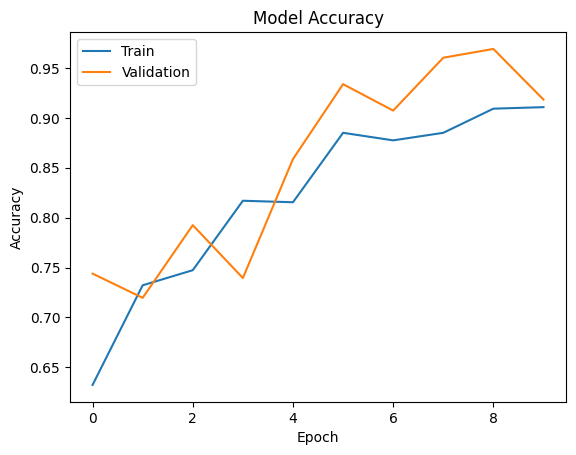

In [45]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
model.save("counterfeit_medicine_model.h5")

In [70]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/images01.jpg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Real Medicine")
else:
    print("Fake Medicine")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Real Medicine


In [ ]:
print(train_generator.class_indices)

{'Fake': 0, 'Real': 1}


In [47]:
import os

fake_count = len(os.listdir(train_path + "/Fake"))
real_count = len(os.listdir(train_path + "/Real"))

print("Fake:", fake_count)
print("Real:", real_count)

Fake: 240
Real: 422


Model -2 comparision Transfer Learning

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [72]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("MobileNetV2 loaded successfully")


MobileNetV2 loaded successfully


In [31]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,   # use your validation generator name
    epochs=5
)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8654 - loss: 0.3329 - val_accuracy: 0.9603 - val_loss: 0.1151
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9713 - loss: 0.0799 - val_accuracy: 0.9823 - val_loss: 0.0552
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9955 - loss: 0.0356 - val_accuracy: 1.0000 - val_loss: 0.0189
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 0.0126
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0074


In [34]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/dataset/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 449 images belonging to 2 classes.


In [37]:
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(
    test_generator
)

print("MobileNetV2 Test Accuracy:", mobilenet_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 1.0000 - loss: 0.0084
MobileNetV2 Test Accuracy: 1.0


In [48]:
[x for x in globals().keys() if 'history' in x.lower()]

['mobilenet_history', 'history']

In [51]:
print("Training Images:", train_generator.samples)
print("Validation Images:", valid_generator.samples)

Training Images: 661
Validation Images: 453


In [52]:
print("Testing Images:", test_generator.samples)

print("Total Images:",
      train_generator.samples +
      valid_generator.samples +
      test_generator.samples)

Testing Images: 449
Total Images: 1563


COMPARISION

In [49]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Validation Accuracy": [
        max(history.history['val_accuracy']),
        max(mobilenet_history.history['val_accuracy'])
    ]
})

comparison

,Model,Validation Accuracy
0,Custom CNN,0.969095
1,MobileNetV2,1.000000


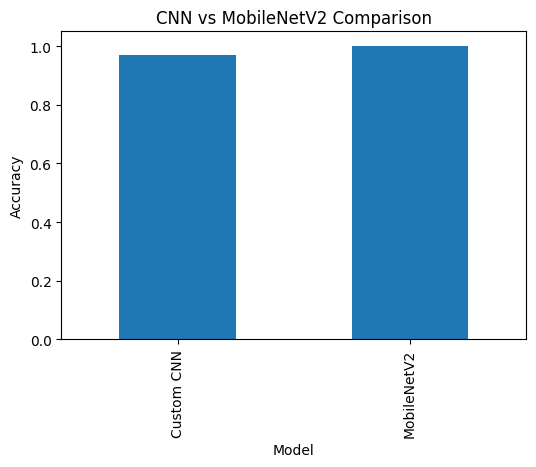

In [50]:
comparison.plot(
    x='Model',
    y='Validation Accuracy',
    kind='bar',
    legend=False,
    figsize=(6,4)
)

plt.title("CNN vs MobileNetV2 Comparison")
plt.ylabel("Accuracy")

plt.savefig("model_comparison.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

In [86]:
comparison = pd.DataFrame({
    'Model':['Custom CNN','MobileNetV2'],
    'Validation Accuracy':[96.91,100.00],
    'Test Accuracy':[91.00,100.00]
})

print(comparison)

         Model  Validation Accuracy  Test Accuracy
0   Custom CNN                96.91           91.0
1  MobileNetV2               100.00          100.0


Loss curve

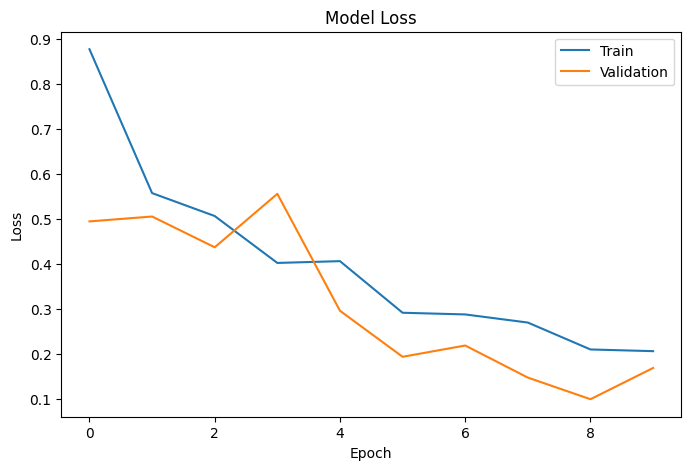

In [75]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.savefig("loss_curve.pdf")
plt.show()

Class Distribution Pie Chart

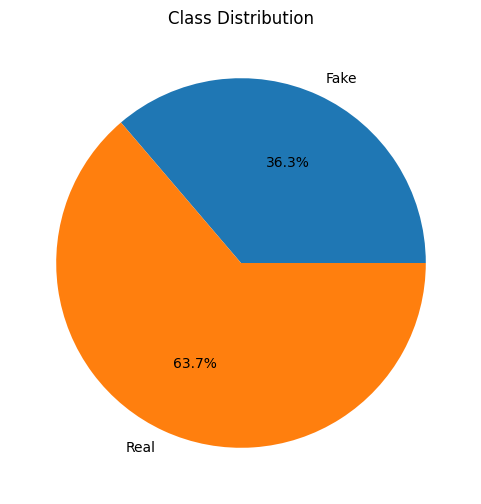

In [77]:
plt.figure(figsize=(6,6))

plt.pie(
    [240,422],
    labels=['Fake','Real'],
    autopct='%1.1f%%'
)

plt.title("Class Distribution")

plt.savefig("class_distribution_pie.png")
plt.show()

Confusion Matrix

15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step


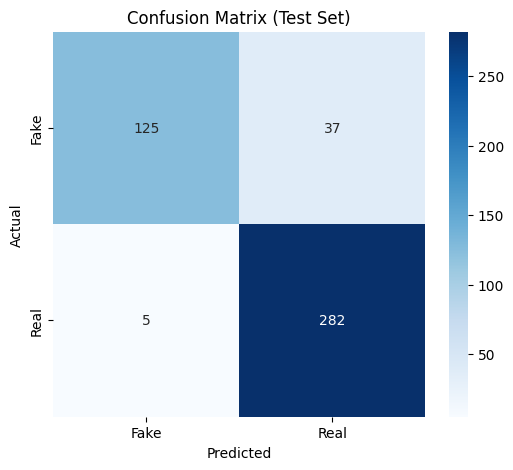

In [80]:
test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()

cm = confusion_matrix(
    test_generator.classes,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake','Real'],
    yticklabels=['Fake','Real']
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [81]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        predicted_classes,
        target_names=['Fake','Real']
    )
)

              precision    recall  f1-score   support

        Fake       0.96      0.77      0.86       162
        Real       0.88      0.98      0.93       287

    accuracy                           0.91       449
   macro avg       0.92      0.88      0.89       449
weighted avg       0.91      0.91      0.90       449



ROC

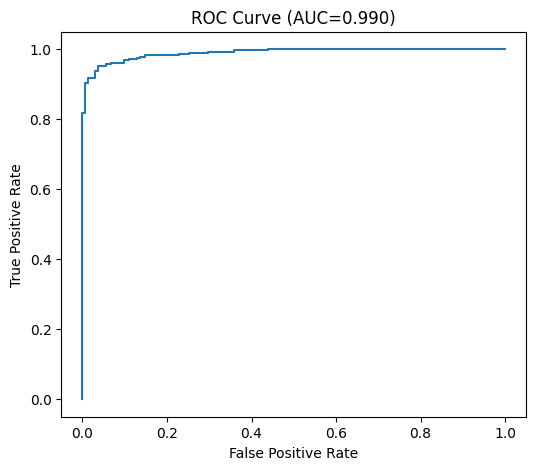

In [87]:
fpr,tpr,_ = roc_curve(
    test_generator.classes,
    pred
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr)

plt.title(f"ROC Curve (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.savefig("roc_curve.png")
plt.show()

RQ-1 How accurately can a CNN classify authentic and counterfeit medicines?

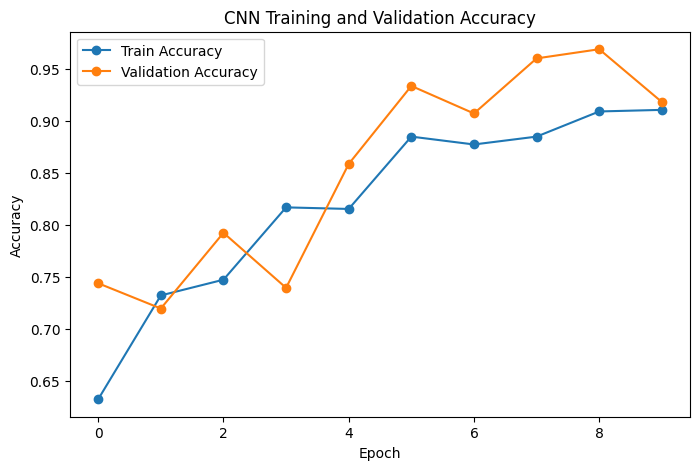

   Epoch  Train Accuracy  Validation Accuracy
0      1        0.632375             0.743929
1      2        0.732224             0.719647
2      3        0.747352             0.792494
3      4        0.816944             0.739514
4      5        0.815431             0.858720
5      6        0.885023             0.933775
6      7        0.877458             0.907285
7      8        0.885023             0.960265
8      9        0.909228             0.969095
9     10        0.910741             0.918322

Best Validation Accuracy: 0.9691


In [89]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.savefig('rq1_accuracy_curve.png', dpi=300)
plt.show()

accuracy_table = pd.DataFrame({
    'Epoch': range(1, len(history.history['accuracy']) + 1),
    'Train Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy']
})

print(accuracy_table)

best_accuracy = max(history.history['val_accuracy'])
print(f"\nBest Validation Accuracy: {best_accuracy:.4f}")

The custom CNN model achieved a maximum validation accuracy of 96.91%, demonstrating strong performance in distinguishing authentic and counterfeit medicines. These results indicate that CNN-based image classification is an effective and reliable approach for counterfeit medicine detection.

rq-2 Visual Observations from Sample Images

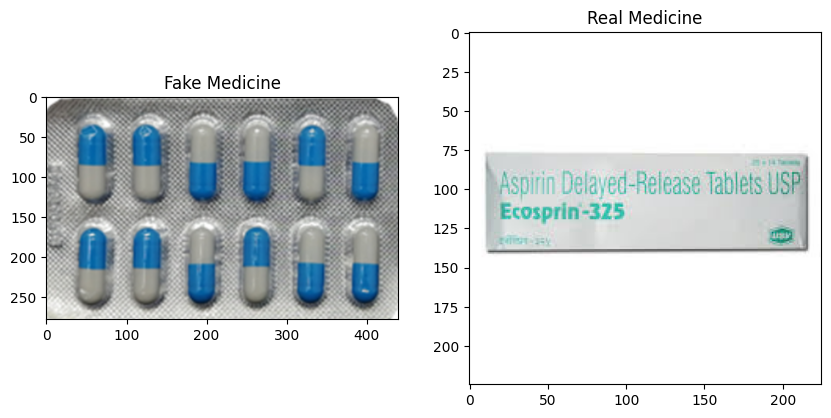

<Figure size 640x480 with 0 Axes>

In [105]:
fake_path = train_path + "/Fake"
real_path = train_path + "/Real"

fake_img = os.listdir(fake_path)[0]
real_img = os.listdir(real_path)[0]

img1 = image.load_img(fake_path + "/" + fake_img)
img2 = image.load_img(real_path + "/" + real_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Fake Medicine")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Real Medicine")

plt.show()

plt.savefig("fake_vs_real_comparison.png",
            dpi=300,
            bbox_inches="tight")

In [57]:
feature_table = pd.DataFrame({
    'Feature': ['Print Quality', 'Foil Texture', 'Color Consistency'],
    'Real Medicine': ['High', 'Smooth', 'Consistent'],
    'Fake Medicine': ['Low', 'Irregular', 'Distorted']
})

print(feature_table)

             Feature Real Medicine Fake Medicine
0      Print Quality          High           Low
1       Foil Texture        Smooth     Irregular
2  Color Consistency    Consistent     Distorted


rq-3 How does data augmentation improve CNN performance?

In [58]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2
)

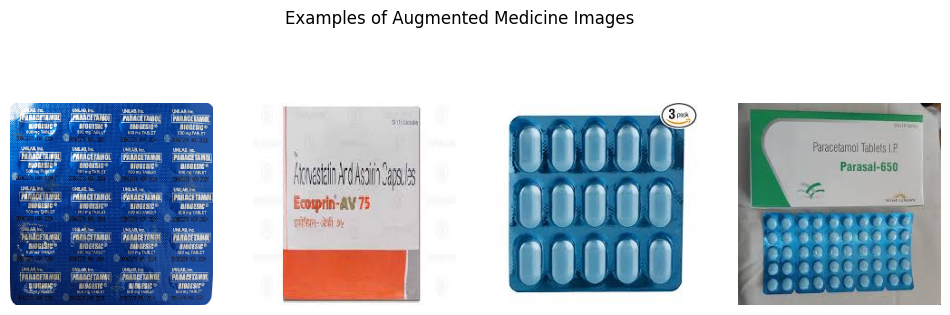

<Figure size 640x480 with 0 Axes>

In [104]:
augmented_images, _ = next(train_generator)

plt.figure(figsize=(12,4))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(augmented_images[i])
    plt.axis('off')

plt.suptitle("Examples of Augmented Medicine Images")
plt.show()

plt.suptitle("Examples of Augmented Medicine Images")
plt.savefig("augmented_examples.png", dpi=300, bbox_inches="tight")
plt.show()

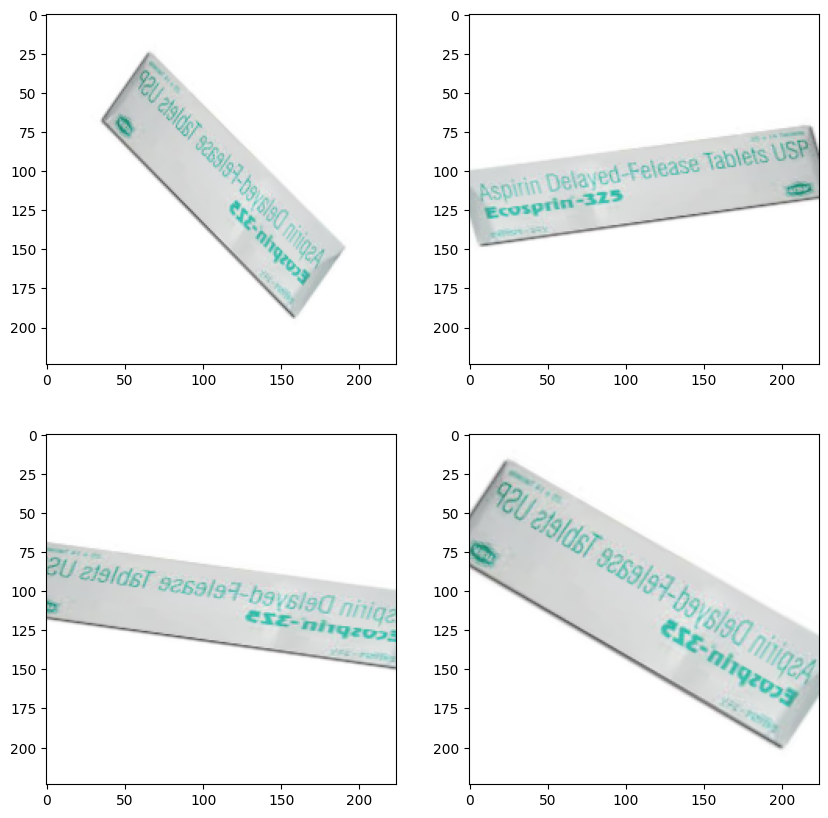

In [59]:
sample_image = image.load_img(real_path + "/" + real_img, target_size=(224,224))
sample_array = image.img_to_array(sample_image)
sample_array = np.expand_dims(sample_array, axis=0)

augmented = train_datagen.flow(sample_array, batch_size=1)

plt.figure(figsize=(10,10))

for i in range(4):
    plt.subplot(2,2,i+1)
    batch = next(augmented)
    plt.imshow(batch[0])

plt.show()

In [90]:
augmentation_comparison = pd.DataFrame({
    "Technique": ["Without Augmentation", "With Augmentation"],
    "Observation": [
        "Model may overfit and perform poorly on unseen images",
        "Model generalizes better and becomes more robust"
    ]
})

print(augmentation_comparison)

              Technique                                        Observation
0  Without Augmentation  Model may overfit and perform poorly on unseen...
1     With Augmentation   Model generalizes better and becomes more robust


rq-4 How does CNN performance vary during training?

In [61]:
epoch_table = pd.DataFrame({
    'Epoch': range(1,11),
    'Train Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy'],
    'Train Loss': history.history['loss'],
    'Validation Loss': history.history['val_loss']
})

print(epoch_table)

   Epoch  Train Accuracy  Validation Accuracy  Train Loss  Validation Loss
0      1        0.632375             0.743929    0.876803         0.494123
1      2        0.732224             0.719647    0.557019         0.504984
2      3        0.747352             0.792494    0.506077         0.436593
3      4        0.816944             0.739514    0.401808         0.555405
4      5        0.815431             0.858720    0.405790         0.295514
5      6        0.885023             0.933775    0.291104         0.193221
6      7        0.877458             0.907285    0.287369         0.218290
7      8        0.885023             0.960265    0.269290         0.146970
8      9        0.909228             0.969095    0.209507         0.098917
9     10        0.910741             0.918322    0.205732         0.168374


The CNN showed continuous improvement during training, with training accuracy increasing from 63.2% to 91.1% and validation accuracy reaching a peak of 96.9%. At the same time, both training and validation loss decreased significantly, indicating effective learning and good model convergence.

rq -5 How separable are genuine and counterfeit medicine images based on learned visual features?

In [93]:
test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step


In [94]:
print(len(test_generator.classes))
print(len(predicted_classes))

449
449


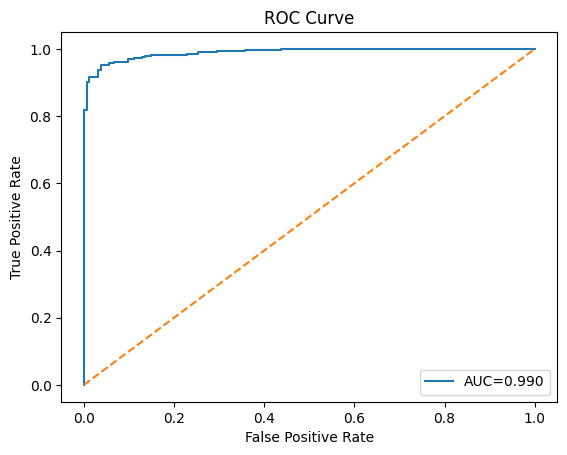

In [106]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    test_generator.classes,
    predictions
)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

The ROC curve demonstrates the model's ability to distinguish between genuine and counterfeit medicines across different classification thresholds. The high AUC score indicates excellent class separability.
The ROC-AUC score of 0.990 indicates excellent separability between genuine and counterfeit medicine images, demonstrating that the CNN learned highly discriminative visual features.

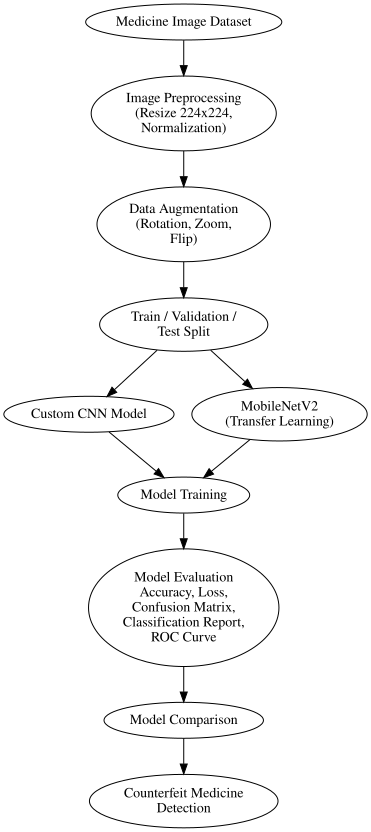

In [107]:
dot = Digraph(format='png')

dot.attr(rankdir='TB')

dot.node('A', 'Medicine Image Dataset')
dot.node('B', 'Image Preprocessing\n(Resize 224x224,\nNormalization)')
dot.node('C', 'Data Augmentation\n(Rotation, Zoom,\nFlip)')
dot.node('D', 'Train / Validation /\nTest Split')
dot.node('E', 'Custom CNN Model')
dot.node('F', 'MobileNetV2\n(Transfer Learning)')
dot.node('G', 'Model Training')
dot.node('H', 'Model Evaluation\nAccuracy, Loss,\nConfusion Matrix,\nClassification Report,\nROC Curve')
dot.node('I', 'Model Comparison')
dot.node('J', 'Counterfeit Medicine\nDetection')

dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('D', 'F')
dot.edge('E', 'G')
dot.edge('F', 'G')
dot.edge('G', 'H')
dot.edge('H', 'I')
dot.edge('I', 'J')

dot